---
categories:
- PPEC
- Ensino
- Estatística
date: 2023-03-16
description: Aula 5 - Notebook sobre Testes de Normalidade e Homocedasticidade
image: Testes_Normalidade_Homocedasticidade.jpg
title: "Testes de Normalidade e Homocedasticidade"
---

<a href="https://colab.research.google.com/github/britobruna/ESTATISTICA-PPEC0039/blob/main/Testes_Normalidade_Homocedasticidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

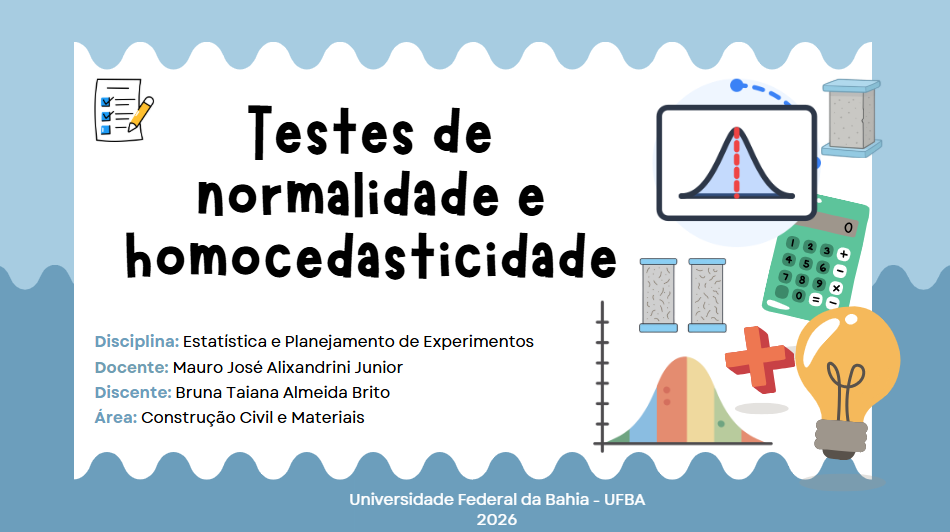

#  1. Testes de normalidade e homocedasticidade
___

<div align="justify">

A análise estatística desempenha papel fundamental no planejamento e interpretação de experimentos. Em ensaios experimentais, é comum comparar diferentes grupos de resultados, verificar diferenças entre tratamentos ou avaliar o comportamento mecânico de materiais. Entretanto, antes da aplicação de diversos testes estatísticos paramétricos, como análise de variância (ANOVA) e regressão linear, é necessário verificar se determinados pressupostos estatísticos são atendidos.

Entre esses pressupostos, destacam-se a normalidade dos dados e a homogeneidade das variâncias (homocedasticidade). A verificação dessas condições é importante para garantir a validade das inferências estatísticas realizadas.

Segundo Montgomery e Runger (2014), a análise prévia da distribuição dos dados e do comportamento das variâncias constitui etapa essencial na interpretação correta de resultados experimentais.

Neste material, serão abordados os principais testes de normalidade e homocedasticidade, incluindo interpretações gráficas, testes analíticos e aplicações computacionais utilizando Python.

</div>

##  1.1 Testes de normalidade

<div align="justify">

Um conjunto de dados apresenta normalidade quando sua distribuição se aproxima da distribuição normal, também conhecida como distribuição Gaussiana.

A distribuição normal possui formato simétrico em torno da média e é amplamente utilizada na modelagem de fenômenos naturais e experimentais. Em engenharia, diversas propriedades mecânicas apresentam comportamento aproximadamente normal, como resistência à compressão, resistência à flexão e módulo de elasticidade.

A verificação da normalidade é importante porque muitos testes estatísticos clássicos assumem que os dados seguem distribuição normal. Caso essa condição não seja atendida, os resultados podem apresentar interpretações inadequadas.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

Os testes de normalidade são ferramentas estatísticas utilizadas para verificar se um conjunto de dados apresenta distribuição aproximadamente normal.

</div>

###  Importância da normalidade

<div align="justify">

A avaliação da normalidade é importante em diversas aplicações estatísticas, principalmente porque muitos métodos paramétricos dependem desse pressuposto.

A verificação da normalidade é frequentemente realizada antes da aplicação de:

- Análise de variância (ANOVA);
- Regressão linear;
- Testes t;
- Análise de médias;
- Planejamento experimental.



</div>

<div align="justify">

A normalidade pode ser avaliada tanto por métodos gráficos quanto por testes analíticos. Entre os métodos gráficos mais utilizados destaca-se o gráfico QQ-Plot, amplamente empregado pela sua simplicidade visual e facilidade de interpretação.

</div>

##  1.1.1 Gráfico QQ-Plot

<div align="justify">

O gráfico QQ-Plot (Quantile-Quantile Plot) é uma ferramenta gráfica utilizada para avaliar se um conjunto de dados apresenta comportamento compatível com uma distribuição teórica, geralmente a distribuição normal.

Nesse método, os quantis observados da amostra são comparados com os quantis esperados da distribuição normal. Quando os pontos se distribuem aproximadamente sobre uma reta, considera-se que os dados apresentam comportamento próximo da normalidade.

Desvios acentuados da reta podem indicar assimetria, presença de outliers ou não aderência à distribuição normal.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O QQ-Plot é um método gráfico utilizado para comparar os quantis observados de uma amostra com os quantis esperados de uma distribuição teórica.

</div>


###  Interpretação do QQ-Plot

<div align="justify">

A interpretação do gráfico é realizada visualmente:

- Pontos próximos da reta indicam comportamento aproximadamente normal;
- Desvios acentuados sugerem não normalidade;
- Curvaturas podem indicar assimetria;
- Pontos extremos afastados podem indicar outliers.

Por se tratar de um método gráfico, recomenda-se complementar a análise com testes analíticos de normalidade.

</div>




<div align="justify">

A construção computacional do QQ-Plot permite visualizar de forma prática o comportamento dos dados experimentais em relação à distribuição normal.

No exemplo a seguir, será gerada uma amostra simulada representando resultados de resistência à flexão de compósitos cimentícios reforçados com fibras. Em seguida, será construído o gráfico QQ-Plot para avaliar visualmente a normalidade dos dados.

</div>

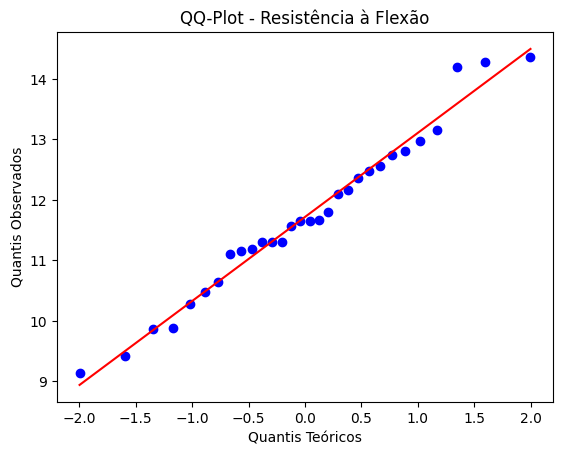

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Gerando amostra simulada
np.random.seed(42)

dados = np.random.normal(loc=12, scale=1.5, size=30)

# Criando QQ-Plot
plt.figure()

stats.probplot(dados, dist="norm", plot=plt)

plt.title("QQ-Plot - Resistência à Flexão")
plt.xlabel("Quantis Teóricos")
plt.ylabel("Quantis Observados")

plt.show()

### Interpretação dos resultados

<div align="justify">

Observa-se que os pontos do gráfico encontram-se próximos da reta de referência, indicando que os dados apresentam comportamento aproximadamente normal.

Pequenos desvios podem ocorrer devido à variabilidade amostral, especialmente em conjuntos de dados reduzidos. Entretanto, quando os pontos seguem tendência linear sem grandes afastamentos, considera-se que o pressuposto de normalidade pode ser aceito visualmente.

Na prática experimental, essa análise auxilia na escolha adequada dos testes estatísticos que poderão ser aplicados posteriormente.

</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Interpretação visual simples;
- Identificação rápida de assimetria e outliers;
- Não depende exclusivamente de p-valores.

###  Limitações
- Interpretação subjetiva;
- Dependência da experiência do analista;
- Não substitui completamente os testes analíticos.

</div>

##  1.1.2 Teste de Shapiro-Wilk

<div align="justify">

O teste de Shapiro-Wilk é um dos testes de normalidade mais utilizados em análises estatísticas, especialmente para pequenas amostras. O método verifica se os dados observados apresentam comportamento compatível com uma distribuição normal, comparando os valores da amostra com os quantis esperados da normalidade.

De forma geral, quanto maior a discrepância entre os dados observados e a distribuição normal teórica, maior a evidência de não normalidade.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Shapiro-Wilk verifica se um conjunto de dados pode ser considerado proveniente de uma distribuição normal.

</div>

### Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $H_0$: os dados seguem distribuição normal;
- Hipótese alternativa $H_1$: os dados não seguem distribuição normal.

A interpretação é realizada por meio do p-valor:

- se $p > 0,05$, não se rejeita $H_0$;
- se $p \leq 0,05$, rejeita-se $H_0$.

Assim, valores elevados de p indicam maior compatibilidade entre os dados observados e a distribuição normal.

</div>
</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Elevado poder estatístico;
- Adequado para pequenas amostras;
- Amplamente utilizado em aplicações experimentais.

###  Limitações
- Sensível à presença de outliers;
- Pode rejeitar normalidade em grandes amostras devido a pequenos desvios.

</div>

<div style="background-color:#fff1f0; padding:15px; border-left:5px solid #ff4d4f">

**Observação Importante:**

A avaliação da normalidade não deve ser realizada exclusivamente por testes analíticos. Recomenda-se combinar testes estatísticos com métodos gráficos, como histogramas e QQ-Plots, permitindo uma interpretação mais robusta dos dados.

</div>

##  1.1.3 Teste de Kolmogorov-Smirnov

<div align="justify">

O teste de Kolmogorov-Smirnov (KS) é um teste estatístico utilizado para avaliar a aderência entre a distribuição observada de uma amostra e uma distribuição teórica de referência, como a distribuição normal.

O método baseia-se na comparação entre as funções distribuição acumulada da amostra e da distribuição teórica esperada. A estatística do teste corresponde à maior diferença observada entre essas duas curvas acumuladas.

De forma geral, quanto maior a discrepância entre as distribuições, maior a evidência de não aderência à distribuição analisada.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Kolmogorov-Smirnov verifica se a distribuição acumulada dos dados observados difere significativamente de uma distribuição teórica especificada.

</div>

###  Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $H_0$: os dados seguem a distribuição teórica especificada;
- Hipótese alternativa $H_1$: os dados não seguem a distribuição teórica especificada.

A interpretação é realizada por meio do p-valor:

- se $p > 0,05$, não se rejeita $H_0$;
- se $p \leq 0,05$, rejeita-se $H_0$.

Quando aplicado à normalidade, a distribuição teórica considerada é a distribuição normal.

</div>

<div style="background-color:#f0f8ff; padding:15px; border-left:5px solid #69b1ff">

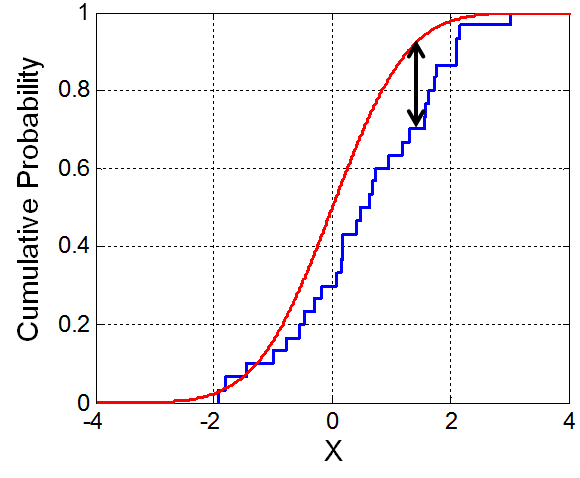

Figura 1. Ilustração da estatística de Kolmogorov–Smirnov. A linha vermelha é a função distribuição acumulada, a linha azul é a função distribuição empírica e a seta preta é a estatística K–S. Fonte: https://pt.wikipedia.org/wiki/Teste_Kolmogorov-Smirnov.

</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Aplicação relativamente simples;
- Pode ser utilizado para diferentes distribuições teóricas;
- Comparação direta entre distribuições acumuladas.

###  Limitações
- Menor poder estatístico em comparação ao Shapiro-Wilk;
- Sensível ao tamanho da amostra;
- Desempenho reduzido quando os parâmetros da distribuição são estimados a partir da própria amostra.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com o teste de Shapiro-Wilk:**

O teste de Shapiro-Wilk geralmente apresenta maior poder estatístico para pequenas amostras, sendo frequentemente preferido em aplicações experimentais.

O teste KS, por outro lado, destaca-se pela comparação direta entre distribuições acumuladas e pela flexibilidade de aplicação em diferentes distribuições teóricas.

</div>

##  1.1.4 Teste de Anderson-Darling

<div align="justify">

O teste de Anderson-Darling é um teste estatístico de aderência utilizado para verificar se um conjunto de dados segue uma distribuição teórica específica, sendo amplamente aplicado na avaliação da normalidade.

Esse método consiste em uma modificação do teste de Kolmogorov-Smirnov, porém atribuindo maior peso às regiões de cauda da distribuição. Dessa forma, o teste torna-se mais sensível à presença de outliers, assimetrias e desvios associados a valores extremos.

Quanto maiores forem as discrepâncias entre os dados observados e a distribuição teórica nas regiões extremas, maior será a evidência de não normalidade.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Anderson-Darling verifica a aderência entre os dados observados e uma distribuição teórica, atribuindo maior sensibilidade às regiões de cauda da distribuição.

</div>

###  Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $H_0$: os dados seguem a distribuição especificada;
- Hipótese alternativa $H_1$: os dados não seguem a distribuição especificada.

A interpretação é realizada a partir da estatística calculada e dos valores críticos associados ao teste:

- Valores menores indicam maior aderência à distribuição;
- Valores maiores indicam possível não aderência.

Em diversos softwares estatísticos, a interpretação também pode ser realizada por meio do p-valor.

</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Elevada sensibilidade a desvios nas caudas;
- Eficiente na detecção de outliers e assimetrias;
- Maior poder estatístico em diversas aplicações.

###  Limitações
- Interpretação menos intuitiva;
- Maior sensibilidade pode levar à rejeição da normalidade por pequenos desvios;
- Depende de valores críticos específicos para cada distribuição.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com outros testes de normalidade:**

O teste de Anderson-Darling geralmente apresenta maior sensibilidade nas extremidades da distribuição quando comparado ao teste KS. Em relação ao teste de Shapiro-Wilk, ambos costumam apresentar bom desempenho, porém o Anderson-Darling destaca-se especialmente em situações envolvendo caudas não normais ou presença de outliers.

</div>

##  1.1.5 Teste de Cramér-von Mises

<div align="justify">

O teste de Cramér-von Mises é um teste estatístico de aderência utilizado para avaliar se um conjunto de dados segue uma distribuição teórica específica, como a distribuição normal.

Assim como os testes KS e Anderson-Darling, o método compara a distribuição acumulada observada da amostra com a distribuição acumulada teórica esperada. Entretanto, diferentemente do teste KS, que considera apenas a maior discrepância observada, o teste de Cramér-von Mises avalia as diferenças ao longo de toda a distribuição.

Essa característica faz com que o método apresente uma análise mais global da aderência entre os dados observados e o modelo teórico.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Cramér-von Mises avalia a aderência entre a distribuição acumulada observada e a distribuição acumulada teórica por meio da soma das discrepâncias observadas ao longo de toda a distribuição.

</div>

###  Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $ H_0 $: os dados seguem a distribuição teórica especificada;
- Hipótese alternativa $ H_1 $: os dados não seguem a distribuição teórica especificada.

A interpretação é realizada por meio da estatística calculada e do respectivo p-valor:

- Valores menores indicam maior aderência à distribuição;
- Valores maiores indicam possíveis desvios em relação à distribuição teórica.

</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Considera toda a distribuição;
- Boa avaliação global da aderência;
- Menos dependente de discrepâncias localizadas.

###  Limitações
- Menor sensibilidade a discrepâncias extremas;
- Menos difundido em aplicações experimentais;
- Interpretação geralmente realizada com auxílio computacional.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com outros testes:**

O teste de Cramér-von Mises apresenta abordagem intermediária entre o teste KS e o Anderson-Darling.

Enquanto o teste KS enfatiza a maior discrepância observada e o Anderson-Darling atribui maior peso às regiões de cauda, o Cramér-von Mises busca avaliar o ajuste global da distribuição de maneira mais uniforme.

</div>

##  1.1.6 Teste de Lilliefors

<div align="justify">

O teste de Lilliefors é uma adaptação do teste de Kolmogorov-Smirnov desenvolvida para situações em que os parâmetros da distribuição normal, como média e desvio padrão, são estimados a partir da própria amostra.

Na prática experimental, essa condição é bastante comum, uma vez que os parâmetros populacionais reais geralmente não são previamente conhecidos. Dessa forma, o teste de Lilliefors torna-se mais adequado para aplicações reais do que o teste KS clássico.

O método compara a distribuição acumulada observada da amostra com a distribuição normal teórica ajustada a partir dos próprios dados experimentais.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Lilliefors verifica a aderência dos dados à distribuição normal quando média e desvio padrão são estimados a partir da própria amostra.

</div>

### Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $ H_0 $: os dados seguem distribuição normal;
- Hipótese alternativa $ H_1 $: os dados não seguem distribuição normal.

A interpretação é realizada por meio do p-valor:

- se $p > 0,05$, não se rejeita $ H_0 $;
- se $p \leq 0,05 $, rejeita-se $ H_0 $.

Assim como nos demais testes de normalidade, recomenda-se interpretar os resultados juntamente com métodos gráficos e análise do contexto experimental.

</div>
</div>

### Vantagens e limitações

<div align="justify">

###  Vantagens
- Adequado para aplicações experimentais reais;
- Corrige limitações do teste KS clássico;
- Simples de interpretar.

###  Limitações
- Menor poder estatístico em comparação ao Shapiro-Wilk;
- Sensível ao tamanho da amostra;
- Menos eficiente para detectar pequenos desvios de normalidade.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Comparação com o teste KS:**

O teste KS clássico pressupõe que os parâmetros da distribuição teórica sejam previamente conhecidos.

O teste de Lilliefors, por outro lado, foi desenvolvido especificamente para situações em que média e desvio padrão são estimados a partir da própria amostra, condição frequentemente encontrada em estudos experimentais.

</div>

#  1.2 Testes de homocedasticidade
___

<div align="justify">

Além da normalidade dos dados, outro pressuposto importante em diversas análises estatísticas é a homocedasticidade, também chamada de homogeneidade das variâncias.

Esse conceito refere-se à condição em que diferentes grupos experimentais apresentam variâncias aproximadamente semelhantes. A verificação desse pressuposto é importante porque muitos testes paramétricos, como a análise de variância (ANOVA), assumem igualdade entre as variâncias dos grupos comparados.

Quando as variâncias apresentam diferenças significativas, os resultados estatísticos podem tornar-se menos confiáveis, comprometendo as interpretações experimentais.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

Homocedasticidade é a condição em que diferentes grupos de dados apresentam variâncias aproximadamente iguais.

</div>

###  Importância da Homocedasticidade

<div align="justify">

A avaliação da homogeneidade das variâncias é frequentemente realizada antes da aplicação de:

- Análise de variância (ANOVA);
- Regressão linear;
- Testes de comparação entre médias;
- Planejamento experimental.

A presença de heterocedasticidade, isto é, variâncias significativamente diferentes entre grupos, pode influenciar diretamente a validade dos resultados estatísticos.

</div>

<div align="justify">

Entre os testes mais utilizados para avaliação da homogeneidade das variâncias destaca-se o teste de Bartlett, amplamente empregado em análises paramétricas quando os dados apresentam distribuição aproximadamente normal.

</div>

## 1.2.1 Teste de Bartlett

<div align="justify">

O teste de Bartlett é um método estatístico utilizado para verificar se diferentes grupos apresentam variâncias homogêneas.

O teste baseia-se na comparação entre as variâncias observadas dos grupos experimentais, avaliando se as diferenças encontradas podem ser atribuídas apenas à variabilidade aleatória.

A estatística do teste é obtida a partir de transformações logarítmicas das variâncias amostrais e segue, aproximadamente, uma distribuição qui-quadrado.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Definição:**

O teste de Bartlett verifica se dois ou mais grupos apresentam variâncias estatisticamente iguais.

</div>

###  Hipóteses e interpretação

<div align="justify">

As hipóteses do teste são:

- Hipótese nula $ H_0 $: as variâncias dos grupos são iguais;
- Hipótese alternativa $ H_1 $: pelo menos uma variância difere das demais.

A interpretação é realizada por meio do p-valor:

- se $ p > 0,05 $, não se rejeita $H_0$;
- se $p \leq 0,05 $, rejeita-se $H_0$.

Assim, valores elevados de p indicam homogeneidade entre as variâncias dos grupos analisados.

</div>

<div style="background-color:#fffbe6; padding:15px; border-left:5px solid #faad14">

**Relação com a normalidade:**

O teste de Bartlett apresenta melhor desempenho quando os dados seguem distribuição aproximadamente normal. Por esse motivo, recomenda-se realizar previamente testes de normalidade antes da aplicação do método.

</div>

###  Vantagens e limitações

<div align="justify">

###  Vantagens
- Simples de aplicar;
- Amplamente utilizado em análises paramétricas;
- Eficiente quando os dados apresentam normalidade.

###  Limitações
- Altamente sensível à não normalidade;
- Presença de outliers pode comprometer os resultados;
- Desempenho reduzido em distribuições assimétricas.

</div>

#  2. Aplicação integrada: resistência à flexão de argamassas com fibras
___


<div align="justify">

Nesta aplicação, será considerado um estudo experimental hipotético envolvendo a resistência à flexão de três grupos de argamassas:

- **REF**: argamassa de referência, sem adição de fibras;
- **PE**: argamassa reforçada com fibras sintéticas de polietileno;
- **SISAL**: argamassa reforçada com fibras naturais de sisal.

O objetivo é verificar se os dados atendem aos pressupostos estatísticos necessários para aplicação de testes paramétricos, especialmente a análise de variância (ANOVA). Para isso, serão avaliadas a normalidade dos dados e a homogeneidade das variâncias entre os grupos.

</div>

<div style="background-color:#f9f0ff; padding:15px; border-left:5px solid #722ed1">

**Objetivo da aplicação:**

Avaliar, por meio de métodos gráficos e testes estatísticos, se os resultados de resistência à flexão dos três grupos de argamassas apresentam distribuição aproximadamente normal e variâncias homogêneas.

</div>

###  Etapas da análise

<div align="justify">

A análise será conduzida em três etapas principais:

1. **Análise gráfica dos dados**, por meio de boxplot e histogramas;
2. **Teste de normalidade**, utilizando o teste de Shapiro-Wilk e QQ-Plot;
3. **Teste de homocedasticidade**, utilizando o teste de Bartlett.

Caso os dados apresentem normalidade e homogeneidade das variâncias, será possível considerar a aplicação de testes paramétricos, como a ANOVA.

</div>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reprodutibilidade dos resultados
np.random.seed(42)

# Dados simulados de resistência à flexão (MPa)
ref = np.random.normal(loc=5.2, scale=0.35, size=12)
pe = np.random.normal(loc=6.1, scale=0.40, size=12)
sisal = np.random.normal(loc=5.8, scale=0.45, size=12)

# Organização em DataFrame
dados = pd.DataFrame({
    "Resistência à flexão (MPa)": np.concatenate([ref, pe, sisal]),
    "Grupo": ["REF"]*len(ref) + ["PE"]*len(pe) + ["SISAL"]*len(sisal)
})

dados

,Resistência à flexão (MPa),Grupo
0,5.373850,REF
1,5.151607,REF
2,5.426691,REF
3,5.733060,REF
4,5.118046,REF
5,5.118052,REF
6,5.752724,REF
7,5.468602,REF
8,5.035684,REF
9,5.389896,REF


###  Análise gráfica inicial

<div align="justify">

Antes da aplicação dos testes estatísticos, é importante realizar uma análise visual dos dados. Essa etapa permite observar tendências gerais, dispersão dos resultados, presença de possíveis valores extremos e diferenças aparentes entre os grupos experimentais.

</div>

<Figure size 640x480 with 0 Axes>

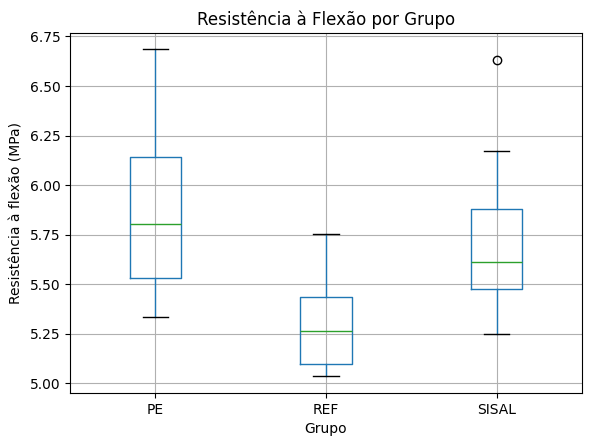

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Reprodutibilidade dos resultados
np.random.seed(42)

# Dados simulados de resistência à flexão (MPa)
ref = np.random.normal(loc=5.2, scale=0.35, size=12)
pe = np.random.normal(loc=6.1, scale=0.40, size=12)
sisal = np.random.normal(loc=5.8, scale=0.45, size=12)

# Organização em DataFrame
dados = pd.DataFrame({
    "Resistência à flexão (MPa)": np.concatenate([ref, pe, sisal]),
    "Grupo": ["REF"]*len(ref) + ["PE"]*len(pe) + ["SISAL"]*len(sisal)
})

plt.figure()

dados.boxplot(column="Resistência à flexão (MPa)", by="Grupo")

plt.title("Resistência à Flexão por Grupo")
plt.suptitle("")
plt.xlabel("Grupo")
plt.ylabel("Resistência à flexão (MPa)")

plt.show()

<div align="justify">

O boxplot permite comparar visualmente a distribuição dos resultados entre os grupos. Observa-se a posição central dos dados, a dispersão e a possível presença de valores extremos.

Neste exemplo, os grupos apresentam diferenças nas medianas, sugerindo variação no desempenho mecânico das argamassas em função da presença e do tipo de fibra. Entretanto, para avaliar estatisticamente essas diferenças, é necessário verificar previamente os pressupostos de normalidade e homocedasticidade.

</div>

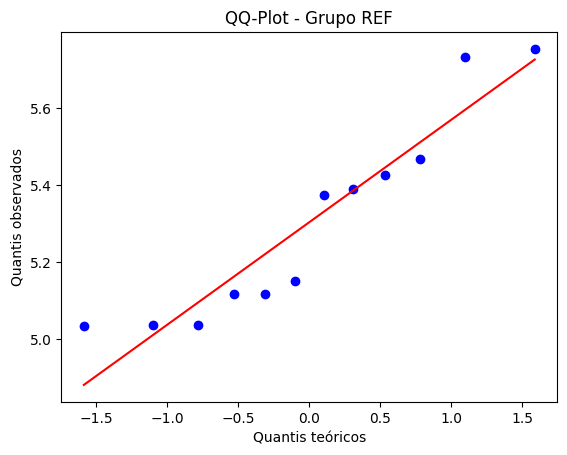

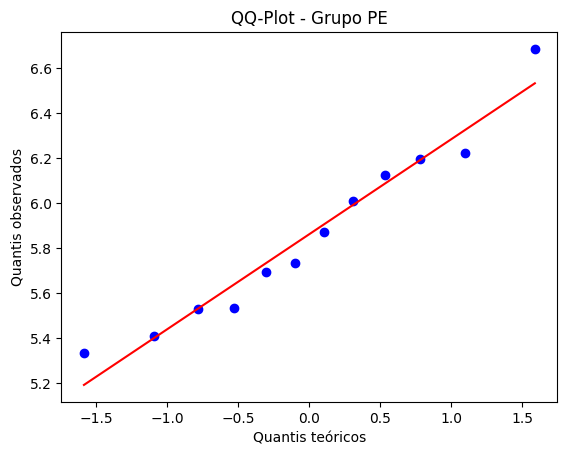

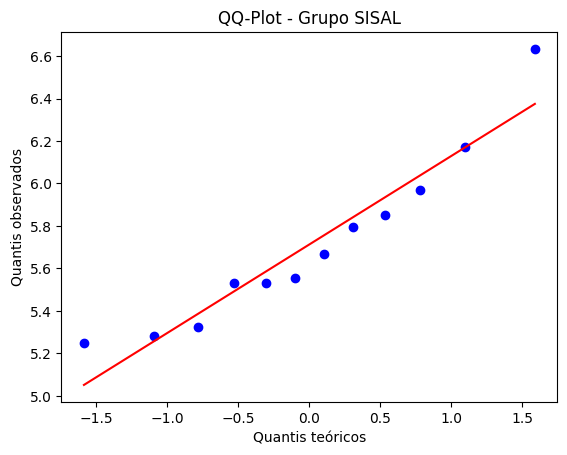

In [8]:
grupos = {"REF": ref, "PE": pe, "SISAL": sisal}

for nome, valores in grupos.items():
    plt.figure()
    stats.probplot(valores, dist="norm", plot=plt)
    plt.title(f"QQ-Plot - Grupo {nome}")
    plt.xlabel("Quantis teóricos")
    plt.ylabel("Quantis observados")
    plt.show()

In [9]:
print("Teste de Shapiro-Wilk")
print("-" * 30)

for nome, valores in grupos.items():
    estatistica, p_valor = stats.shapiro(valores)
    print(f"{nome}: estatística = {estatistica:.4f}, p-valor = {p_valor:.4f}")

Teste de Shapiro-Wilk
------------------------------
REF: estatística = 0.8703, p-valor = 0.0660
PE: estatística = 0.9532, p-valor = 0.6846
SISAL: estatística = 0.9177, p-valor = 0.2676


###  Interpretação do teste de normalidade

<div align="justify">

O teste de Shapiro-Wilk foi aplicado separadamente para cada grupo experimental.

A interpretação segue o seguinte critério:

- se $p > 0,05$, não se rejeita a hipótese de normalidade;
- se $p \leq 0,05 $, rejeita-se a hipótese de normalidade.

Assim, quando os três grupos apresentam p-valores superiores a 0,05, considera-se que os dados possuem comportamento aproximadamente normal, permitindo avançar para a avaliação da homocedasticidade.

</div>

In [10]:
estatistica_bartlett, p_bartlett = stats.bartlett(ref, pe, sisal)

print("Teste de Bartlett")
print("-" * 30)
print(f"Estatística = {estatistica_bartlett:.4f}")
print(f"p-valor = {p_bartlett:.4f}")

Teste de Bartlett
------------------------------
Estatística = 2.3541
p-valor = 0.3082


###  Interpretação do teste de homocedasticidade

<div align="justify">

O teste de Bartlett foi utilizado para verificar se as variâncias dos três grupos podem ser consideradas estatisticamente semelhantes.

A interpretação segue o seguinte critério:

- se $p > 0,05$, não se rejeita a hipótese de igualdade das variâncias;
- se $p \leq 0,05$, rejeita-se a hipótese de igualdade das variâncias.

Caso o p-valor seja superior a 0,05, considera-se que o pressuposto de homocedasticidade foi atendido.

</div>

###  Conclusão da aplicação

<div align="justify">

Com base na análise gráfica, nos QQ-Plots, no teste de Shapiro-Wilk e no teste de Bartlett, é possível avaliar se os dados simulados atendem aos pressupostos necessários para aplicação de testes paramétricos.

Se os grupos apresentarem distribuição aproximadamente normal e variâncias homogêneas, a análise poderá prosseguir para uma comparação estatística entre as médias, como a ANOVA.

No contexto da engenharia de materiais, essa sequência de análise é importante porque evita interpretações equivocadas sobre o efeito das fibras na resistência à flexão das argamassas. Assim, antes de concluir que determinado reforço melhora o desempenho mecânico, é necessário verificar se os pressupostos estatísticos da análise foram atendidos.

</div>

#  **Referências**



ANDERSON, T. W.; DARLING, D. A. "A test of goodness of fit". *Journal of the American Statistical Association*, v. 49, n. 268, p. 765–769, 1954.

BARTLETT, M. S. Properties of sufficiency and statistical tests. *Proceedings of the Royal Society of London*, Series A, v. 160, n. 901, p. 268–282, 1937.

CRAMÉR, H. On the composition of elementary errors. *Scandinavian Actuarial Journal*, v. 1928, n. 1, p. 13–74, 1928.

DEVORE, J. L. Probabilidade e estatística: para engenharia e ciências. (tradução Joaquim Pinheiro Nunes da Silva). São Paulo: Cengage Learning, 2006.

KOLMOGOROV, A. N. Sulla determinazione empirica di una legge di distribuzione. *Giornale dell'Istituto Italiano degli Attuari*, v. 4, p. 83–91, 1933.

LEVENE, H. Robust tests for equality of variances. In: OLKIN, I. et al. (org.). *Contributions to Probability and Statistics*. Stanford: Stanford University Press, 1960. p. 278–292.

LILLIEFORS, H. W. On the Kolmogorov-Smirnov test for normality with mean and variance unknown. *Journal of the American Statistical Association*, v. 62, n. 318, p. 399–402, 1967.

MONTGOMERY, D. C.; RUNGER, G. C. *Applied Statistics and Probability for Engineers*. 6. ed. Hoboken: Wiley, 2014.

RAZALI, N. M.; WAH, Y. B. Power comparisons of Shapiro-Wilk, Kolmogorov-Smirnov, Lilliefors and Anderson-Darling tests. *Journal of Statistical Modeling and Analytics*, v. 2, n. 1, p. 21–33, 2011.

SHAPIRO, S. S.; WILK, M. B. An analysis of variance test for normality. *Biometrika*, v. 52, n. 3–4, p. 591–611, 1965.

SMIRNOV, N. Table for estimating the goodness of fit of empirical distributions. *The Annals of Mathematical Statistics*, v. 19, n. 2, p. 279–281, 1948.

VON MISES, R. Wahrscheinlichkeit, Statistik und Wahrheit. Viena: Julius Springer, 1928.
